In [1]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path
import warnings
import io
from contextlib import contextmanager, redirect_stdout, redirect_stderr

import cortex
# os.environ["PATH"] = os.environ["PATH"] + ":/share/nklab/users/pf2477/bin"
# os.environ.setdefault("LANG","C.UTF-8") # (optional) locales, purely to quiet warnings
# os.environ.setdefault("LC_ALL","C.UTF-8")

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Suppress warnings and output for cleaner execution
@contextmanager
def suppress_print():
    """Silence stdout/stderr and warnings inside the with-block."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        f, e = io.StringIO(), io.StringIO()
        with redirect_stdout(f), redirect_stderr(e):
            yield

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

In [2]:
import os, re, subprocess as sp
from shutil import which
from cortex.testing_utils import inkscape_version
print("Inkscape version:", inkscape_version())


def has_installed(name):
    return which(name) is not None

def inkscape_version():
    if not has_installed('inkscape'):
        return None

    env = os.environ.copy()
    env.setdefault('LANG', 'C.UTF-8')
    env.setdefault('LC_ALL', 'C.UTF-8')

    # Capture both stdout and stderr so warnings don't hide the version line
    proc = sp.run(
        ['inkscape', '--version'],
        stdout=sp.PIPE,
        stderr=sp.STDOUT,   # merge stderr into stdout
        text=True,
        env=env
    )
    out = proc.stdout or ""

    # Look for "Inkscape <version>"
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', out)
    return m.group(1) if m else None

print(f"Inkscape version: {inkscape_version()}")

Inkscape version: should
Inkscape version: 1.3


In [3]:
!inkscape --version

Setting _INKSCAPE_GC=disable as a workaround for broken libgc
You should not use AppImage in production, but you can speedup the AppImage by following this guide: https://inkscape.org/learn/appimage/

(process:86743): Gtk-WARNING **: 22:18:07.310: Locale not supported by C library.
	Using the fallback 'C' locale.
Unable to init server: Could not connect: Connection refused
Inkscape 1.3 (0e150ed, 2023-07-21)


In [4]:
import shutil, os, subprocess as sp

def robust_inkscape_version():
    env = os.environ.copy()
    env.setdefault('LANG','C.UTF-8'); env.setdefault('LC_ALL','C.UTF-8')
    p = sp.run(['inkscape','--version'], stdout=sp.PIPE, stderr=sp.STDOUT, text=True, env=env)
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', p.stdout or "")
    return m.group(1) if m else '0'   # fallback minimal

import cortex, cortex.svgoverlay as svo
svo.INKSCAPE_VERSION = robust_inkscape_version()
print("Patched INKSCAPE_VERSION =", svo.INKSCAPE_VERSION)

Patched INKSCAPE_VERSION = 1.3


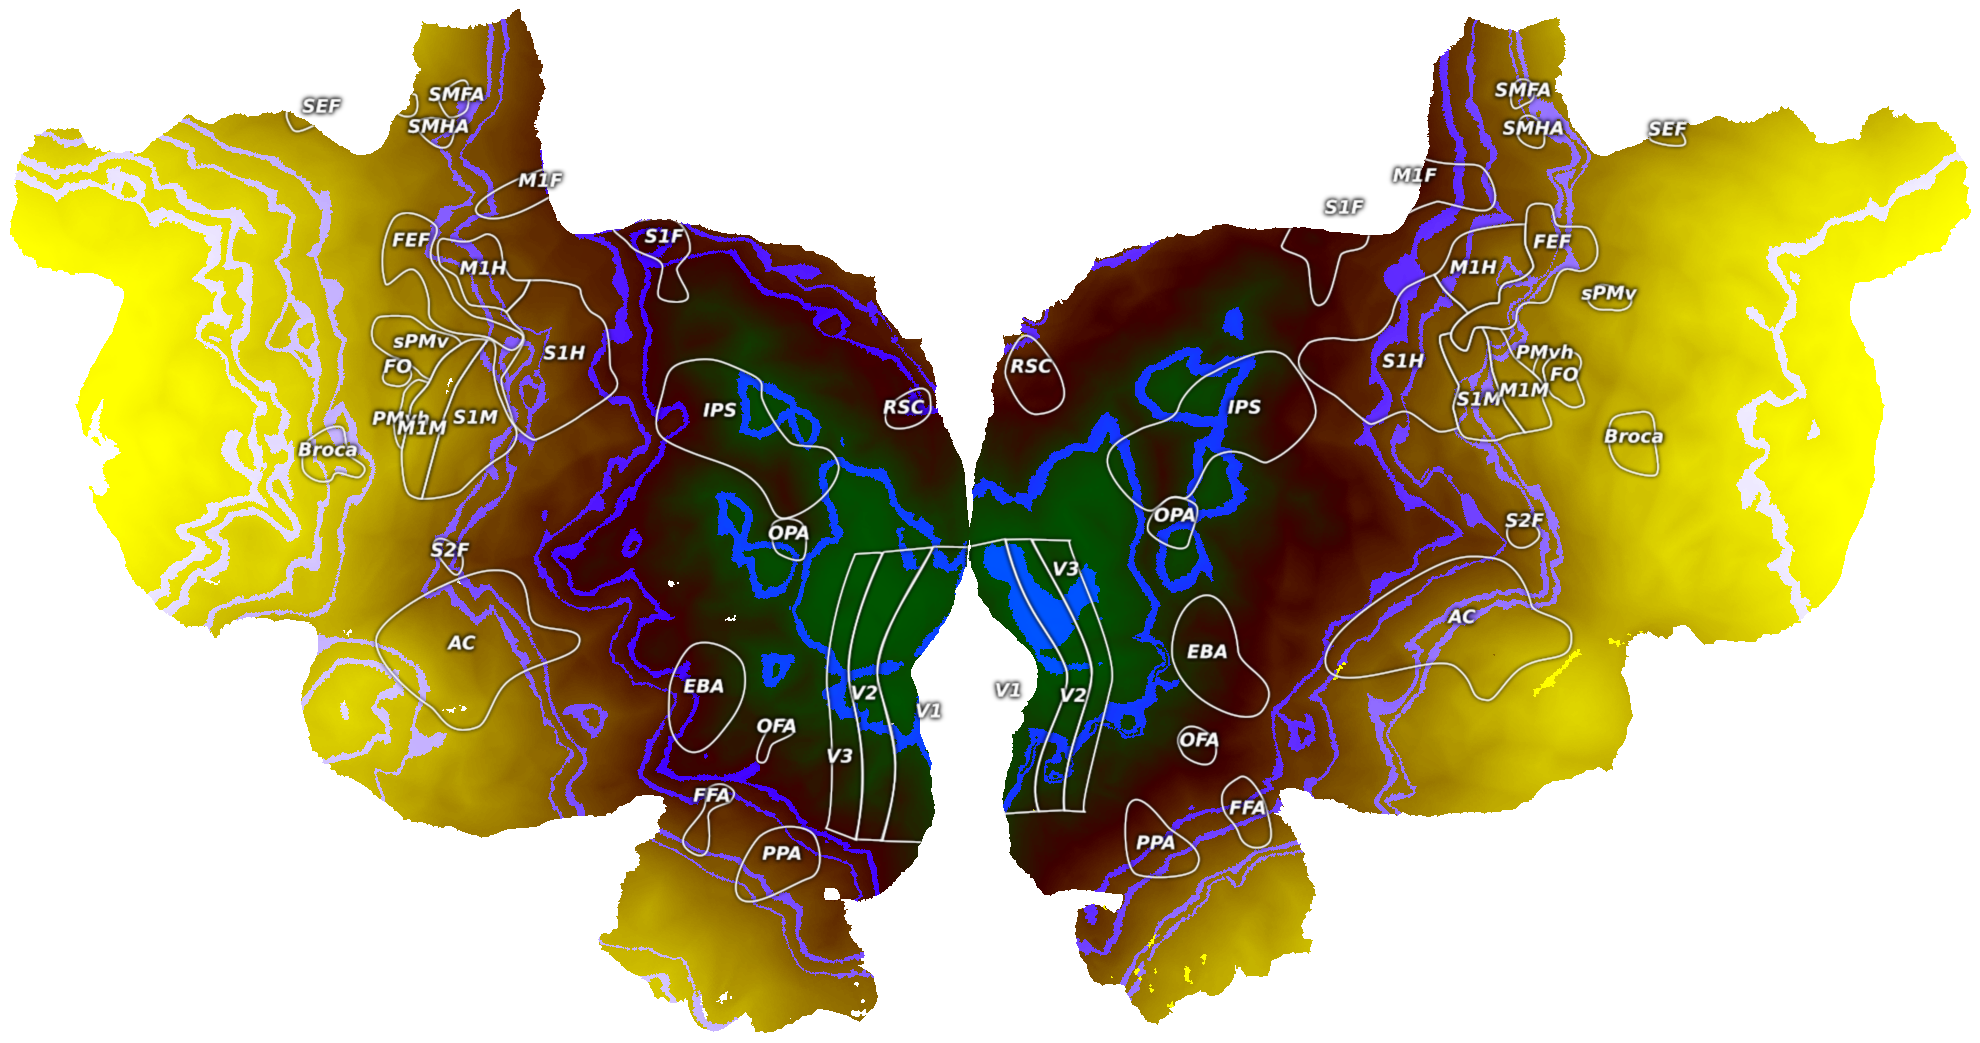

In [5]:
import cortex
import cortex.polyutils
import numpy as np
np.random.seed(1234)
import matplotlib.pyplot as plt

from io import StringIO
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont


subject = 'S1'

# In order to get the number of vertices in this subject's cortical surface
# we have to load in their surfaces and get the number of points in each
surfs = [cortex.polyutils.Surface(*d)
         for d in cortex.db.get_surf(subject, "fiducial")]

# This is the total number of vertices in the left and right hemispheres
num_verts = [s.pts.shape[0] for s in surfs]

# Creating one fake dataset that is basically a gradient across each
# hemisphere based on vertex number
test1 = np.hstack((np.arange(num_verts[0]), np.arange(num_verts[1])))

# Picking a different vertex in each hemisphere to create another fake
# gradient away from that vertex
second_verts = [n / 4 for n in num_verts]
test2 = np.hstack((np.abs(np.arange(num_verts[0]) - second_verts[0]),
                   np.abs(np.arange(num_verts[1]) - second_verts[1])))

# Creating a third dataset that is random stripes
third_verts = np.random.randint(num_verts[0] + num_verts[1], size=(20,))
test3 = np.zeros(num_verts[0] + num_verts[1])
for v in third_verts:
    test3[v-1000: v+1000] = 1

# Scaling the three datasets to be between 0-255
test1_scaled = test1 / np.max(test1) * 255
test2_scaled = test2 / np.max(test2) * 255
test3_scaled = test3 / np.max(test3) * 255

# Creating three cortex.Volume objects with the test data as np.uint8
red = cortex.Vertex(test1_scaled, subject)
green = cortex.Vertex(test2_scaled, subject)
blue = cortex.Vertex(test3_scaled, subject)

# This creates a 2D Vertex object with both of our test datasets for the
# given subject
vertex_data = cortex.VertexRGB(red, green, blue, subject)
with suppress_print():
    cortex.quickshow(vertex_data, with_colorbar=False)
plt.show()

In [6]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

print("\n" + "="*50)
print("Testing nsd_topk_parcel_dataset (single subject)")
print("="*50)
train_dataset = nsd_topk_parcel_dataset(args, split='test', transform=None, topk=args.topk)
print(len(train_dataset), "samples in the dataset")
print(train_dataset.selected_parcel_idx)
print(len(train_dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(train_dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

data = train_dataset[0]
print()
print("\nOutput shapes:")
print(f"img_encoder: {data['img_encoder'].shape}")
print(f"img_ipadapter: {data['img_ipadapter'].shape}")
print(f"brain_lh_f: {data['brain_lh_f'].shape}")
print(f"brain_rh_f: {data['brain_rh_f'].shape}")

Setting up test configuration for subject  1

Testing nsd_topk_parcel_dataset (single subject)
Training on subject: 1
515 samples in the dataset
{'lh': array([  2,  21,  26,  27,  11,   0,   1, 157,   3, 158,  45,  24, 160,
        22,   9,  14, 151,  41,  20,  28,  18, 161,  15, 475,  32, 473,
         8, 159,  23, 163,  31,  17,  25, 166,  44, 164,  19, 467,  10,
       181,  29,  47, 155,   6, 154, 469, 156,   5,  12, 210, 476, 162,
        13, 170,  16, 167,  30,  33, 477,   7, 493, 370, 468, 369, 149,
        56, 377, 367,  46, 171, 213, 165, 172,   4, 153, 481, 495, 152,
       435, 182, 186, 323, 497, 174, 173, 358, 150, 482, 237, 471, 474,
        52, 247, 198, 483, 396, 325, 271, 184, 196]), 'rh': array([ 35,  39,  21,  10, 153,  37, 155,   2,  23,   4,   0, 154,  20,
       152,  42,  19, 151,  15,  36,   8, 302,  13,  43,  28,  41,  29,
       308,  17,  25, 147,   9,  24,  18, 390, 424,  14, 496,   1,  49,
        40, 162, 161, 305, 453, 389,  16, 333, 163, 175,  31, 149,  

In [7]:
neural_data_path = Path(
        "/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data"
    )
metadata = np.load(
    neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True
).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

roi = all_roi_names[0]
print(metadata['lh_rois'][roi])
print(len(metadata['lh_rois'][roi]))
# print([id for id, val in enumerate(metadata['lh_rois'][roi]) if val == True])

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(train_dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print("DOMINANT ROI PER PARCEL (>10% overlap)")
print("="*50)

for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        if roi_name and roi_name in ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4']:
            print(f"Parcel {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
            cnt += 1
        # else:
        #     print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
[False False False ... False False False]
163842
Processing 100 LH parcels with matrix operations...


LH:   0%|          | 0/100 [00:00<?, ?it/s]

LH: 100%|██████████| 100/100 [00:00<00:00, 280.33it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 285.71it/s]


DOMINANT ROI PER PARCEL (>10% overlap)

LH Hemisphere:
Parcel   2: V1d                  (67.9%) in 184 Schaefer voxels
Parcel  26: V2d                  (81.8%) in 192 Schaefer voxels
Parcel  27: V3d                  (52.0%) in 204 Schaefer voxels
Parcel  11: V2v                  (55.4%) in 408 Schaefer voxels
Parcel   0: V1v                  (55.0%) in 318 Schaefer voxels
Parcel   1: V1v                  (87.1%) in 233 Schaefer voxels
Parcel   3: V1d                  (100.0%) in 241 Schaefer voxels
Parcel  24: V3d                  (54.0%) in 326 Schaefer voxels
Parcel  22: V1d                  (69.3%) in 218 Schaefer voxels
Parcel  14: V3v                  (63.5%) in 148 Schaefer voxels
Parcel  41: V1d                  (77.8%) in 162 Schaefer voxels
Parcel  18: V3d                  (50.9%) in 216 Schaefer voxels
Parcel   8: hV4                  (75.3%) in 178 Schaefer voxels
Parcel  12: hV4                  (59.6%) in 225 Schaefer voxels
Parcel  13: V3v                  (50.0%) in 222

In [8]:
if min_overlap_threshold == 0.75:
    roi_groups = {
        # Early / retinotopic visual
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["FFA-1", "FFA-2"],
        "Body": ["FBA-2", "EBA"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "mfs-words"],
    }

if min_overlap_threshold == 0.5:
    roi_groups = {
        # Early / retinotopic visual
        "V1":  ["V1v", "V1d"],
        "V2":  ["V2v", "V2d"],
        "V3":  ["V3v", "V3d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["FFA-1", "FFA-2", "OFA"],
        "Body": ["FBA-2", "EBA"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "OWFA", "mfs-words"],
    }

if min_overlap_threshold <= 0.25:
    roi_groups = {
        # Early / retinotopic visual
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V3": ["V3v", "V3d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["OFA", "FFA-1", "FFA-2"],
        "Body": ["EBA", "FBA-1", "FBA-2"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "OWFA", "mfs-words"],
    }

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cortex

def visualize_parcels_by_roi(
    dataset, metadata, dominant_rois, all_roi_names, subject="fsaverage",
    unlabeled_name="Unlabeled Parcels", unlabeled_color=(0.8, 0.8, 0.8, 1.0),  
    unrecorded_name="Unrecorded Areas", unrecorded_color=(0.2, 0.2, 0.2, 1.0),  # Dark gray
    with_curvature=True, legend_cols=3, show_unlabeled_in_legend=True,
    roi_group=None
):
    """
    Visualize parcels colored by their dominant ROI labels.
    Now distinguishes between unlabeled parcels and unrecorded brain areas.
    
    Args:
        dataset: The brain dataset with parcel information
        metadata: Brain metadata with ROI mappings
        dominant_rois: ROI assignments per parcel from get_dominant_roi_per_parcel
        all_roi_names: List of all ROI names
        subject: Pycortex subject name (default: "fsaverage")
        unlabeled_name: Name for parcels without ROI labels
        unlabeled_color: Color for unlabeled parcels (light red)
        unrecorded_name: Name for brain areas not covered by any parcel
        unrecorded_color: Color for unrecorded areas (dark gray)
        with_curvature: Whether to show brain curvature
        legend_cols: Number of columns in legend
        show_unlabeled_in_legend: Whether to include unlabeled parcels in legend
        roi_group: List of ROI names to visualize. If specified, only these ROIs will be shown
                  with distinct colors, while all other parcels become unlabeled.
                  If None, all ROIs are visualized as before.
    """
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)

    # 1) Collect only matched ROIs (skip None) and count unlabeled
    matched_roi_order = []
    seen = set()
    unlabeled_count = 0
    total_parcels = 0
    
    for hemi in ("lh", "rh"):
        for (_pid, roi_name, _overlap, _nvox) in dominant_rois[hemi]:
            total_parcels += 1
            # If roi_group is specified, only include ROIs that are in the group
            if roi_name is not None:
                if roi_group is None:
                    # Original behavior - include all ROIs
                    if roi_name not in seen:
                        seen.add(roi_name)
                        matched_roi_order.append(roi_name)
                else:
                    # New behavior - only include ROIs in the specified group
                    if roi_name in roi_group and roi_name not in seen:
                        seen.add(roi_name)
                        matched_roi_order.append(roi_name)
                    else:
                        # ROI not in group, treat as unlabeled
                        unlabeled_count += 1
            else:
                unlabeled_count += 1

    # 3-level mapping: 0 = unrecorded areas, 1 = unlabeled parcels, 2+ = ROI parcels
    roi_list = [unrecorded_name, unlabeled_name] + matched_roi_order
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # 2) Use correct hemisphere sizes for fsaverage
    if subject == "fsaverage":
        lh_hemi_size = 163842  # Standard fsaverage left hemisphere vertex count
        rh_hemi_size = 163842  # Standard fsaverage right hemisphere vertex count
    else:
        # For other subjects, get from metadata or surface
        lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
        rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))

    # 3) Init labels - start with 0 (unrecorded areas)
    lh_labels = np.zeros(lh_hemi_size, dtype=np.int32)
    rh_labels = np.zeros(rh_hemi_size, dtype=np.int32)

    # 4) Paint parcels
    sel_vox = dataset.get_selected_voxel_indices()
    for hemi, labels in (("lh", lh_labels), ("rh", rh_labels)):
        hemi_size = lh_hemi_size if hemi == "lh" else rh_hemi_size
        for pos, (_pid, roi_name, _overlap, _nvox) in enumerate(dominant_rois[hemi]):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0:
                continue
            
            # Make sure voxel indices are within bounds
            valid_vox = vox[vox < hemi_size]
            if len(valid_vox) > 0:
                if roi_name is not None and (roi_group is None or roi_name in roi_group):
                    # ROI-labeled parcel that's in our group (or no group specified)
                    idx = roi_to_idx[roi_name]
                else:
                    # Unlabeled parcel (either None ROI or not in specified group)
                    idx = 1
                labels[valid_vox] = idx

    # 5) Create 3-level colormap: unrecorded (dark gray) + unlabeled (light red) + ROI colors
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(matched_roi_order))  # number of matched ROIs
    reps = int(np.ceil(need / 19.0))
    palette = np.vstack([base[1:],] * reps)[:need]  # skip one for variety
    
    # Combine: unrecorded + unlabeled + ROI colors
    all_colors = np.vstack([
        np.array(unrecorded_color)[None, :],  # Index 0: unrecorded areas
        np.array(unlabeled_color)[None, :],   # Index 1: unlabeled parcels
        palette                               # Index 2+: ROI parcels
    ])
    cmap = ListedColormap(all_colors)

    # 6) Visualize with pycortex (no internal colorbar)
    data = np.concatenate([lh_labels, rh_labels])
    print(f"Cortex data shape: {data.shape} (expected: {lh_hemi_size + rh_hemi_size})")
    if roi_group is not None:
        print(f"ROI Group Filter: {roi_group}")
        print(f"Showing {len(matched_roi_order)} ROIs from group, {unlabeled_count}/{total_parcels} parcels as unlabeled ({unlabeled_count/total_parcels:.1%})")
    else:
        print(f"ROI Summary: {len(matched_roi_order)} labeled ROIs, {unlabeled_count}/{total_parcels} unlabeled parcels ({unlabeled_count/total_parcels:.1%})")
    
    # Count unrecorded areas
    unrecorded_vertices = np.sum(data == 0)
    parcel_vertices = np.sum(data > 0)
    print(f"Coverage: {parcel_vertices:,} parcel vertices, {unrecorded_vertices:,} unrecorded vertices")
    
    v = cortex.Vertex(data, subject=subject, cmap=cmap, vmin=0, vmax=len(roi_list)-1)
    with suppress_print():
        cortex.quickshow(v, with_curvature=with_curvature, with_colorbar=False)

    # 7) Build a categorical legend with all three categories
    patches = []
    
    # Add unrecorded areas
    patches.append(mpatches.Patch(
        color=unrecorded_color, 
        label=f"{unrecorded_name}"
    ))
    
    # Add unlabeled parcels if requested and there are unlabeled parcels
    if show_unlabeled_in_legend and unlabeled_count > 0:
        patches.append(mpatches.Patch(
            color=unlabeled_color, 
            label=f"{unlabeled_name}"
        ))
    
    # Add ROI patches
    for i, name in enumerate(matched_roi_order):
        roi_idx = i + 2  # ROIs start at index 2
        patches.append(mpatches.Patch(color=cmap(roi_idx), label=name))

    # Place legend below figure
    fig = plt.gcf()
    if patches:
        fig.legend(
            handles=patches,
            loc="lower center",
            ncol=min(legend_cols, len(patches)),
            fontsize="small",
            frameon=False,
            bbox_to_anchor=(0.5, -0.02)
        )
        plt.subplots_adjust(bottom=0.18)  # make room for legend

    plt.show()
    
    return {
        'matched_rois': matched_roi_order,
        'unlabeled_count': unlabeled_count,
        'total_parcels': total_parcels,
        'unrecorded_vertices': unrecorded_vertices,
        'parcel_vertices': parcel_vertices,
        'labeling_rate': (total_parcels - unlabeled_count) / total_parcels,
        'parcel_coverage': parcel_vertices / (parcel_vertices + unrecorded_vertices)
    }

Visualizing only visual ROIs (V1-V4), all other parcels shown as unlabeled:
Cortex data shape: (327684,) (expected: 327684)
ROI Group Filter: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4']
Showing 7 ROIs from group, 193/200 parcels as unlabeled (96.5%)
Coverage: 51,543 parcel vertices, 276,141 unrecorded vertices


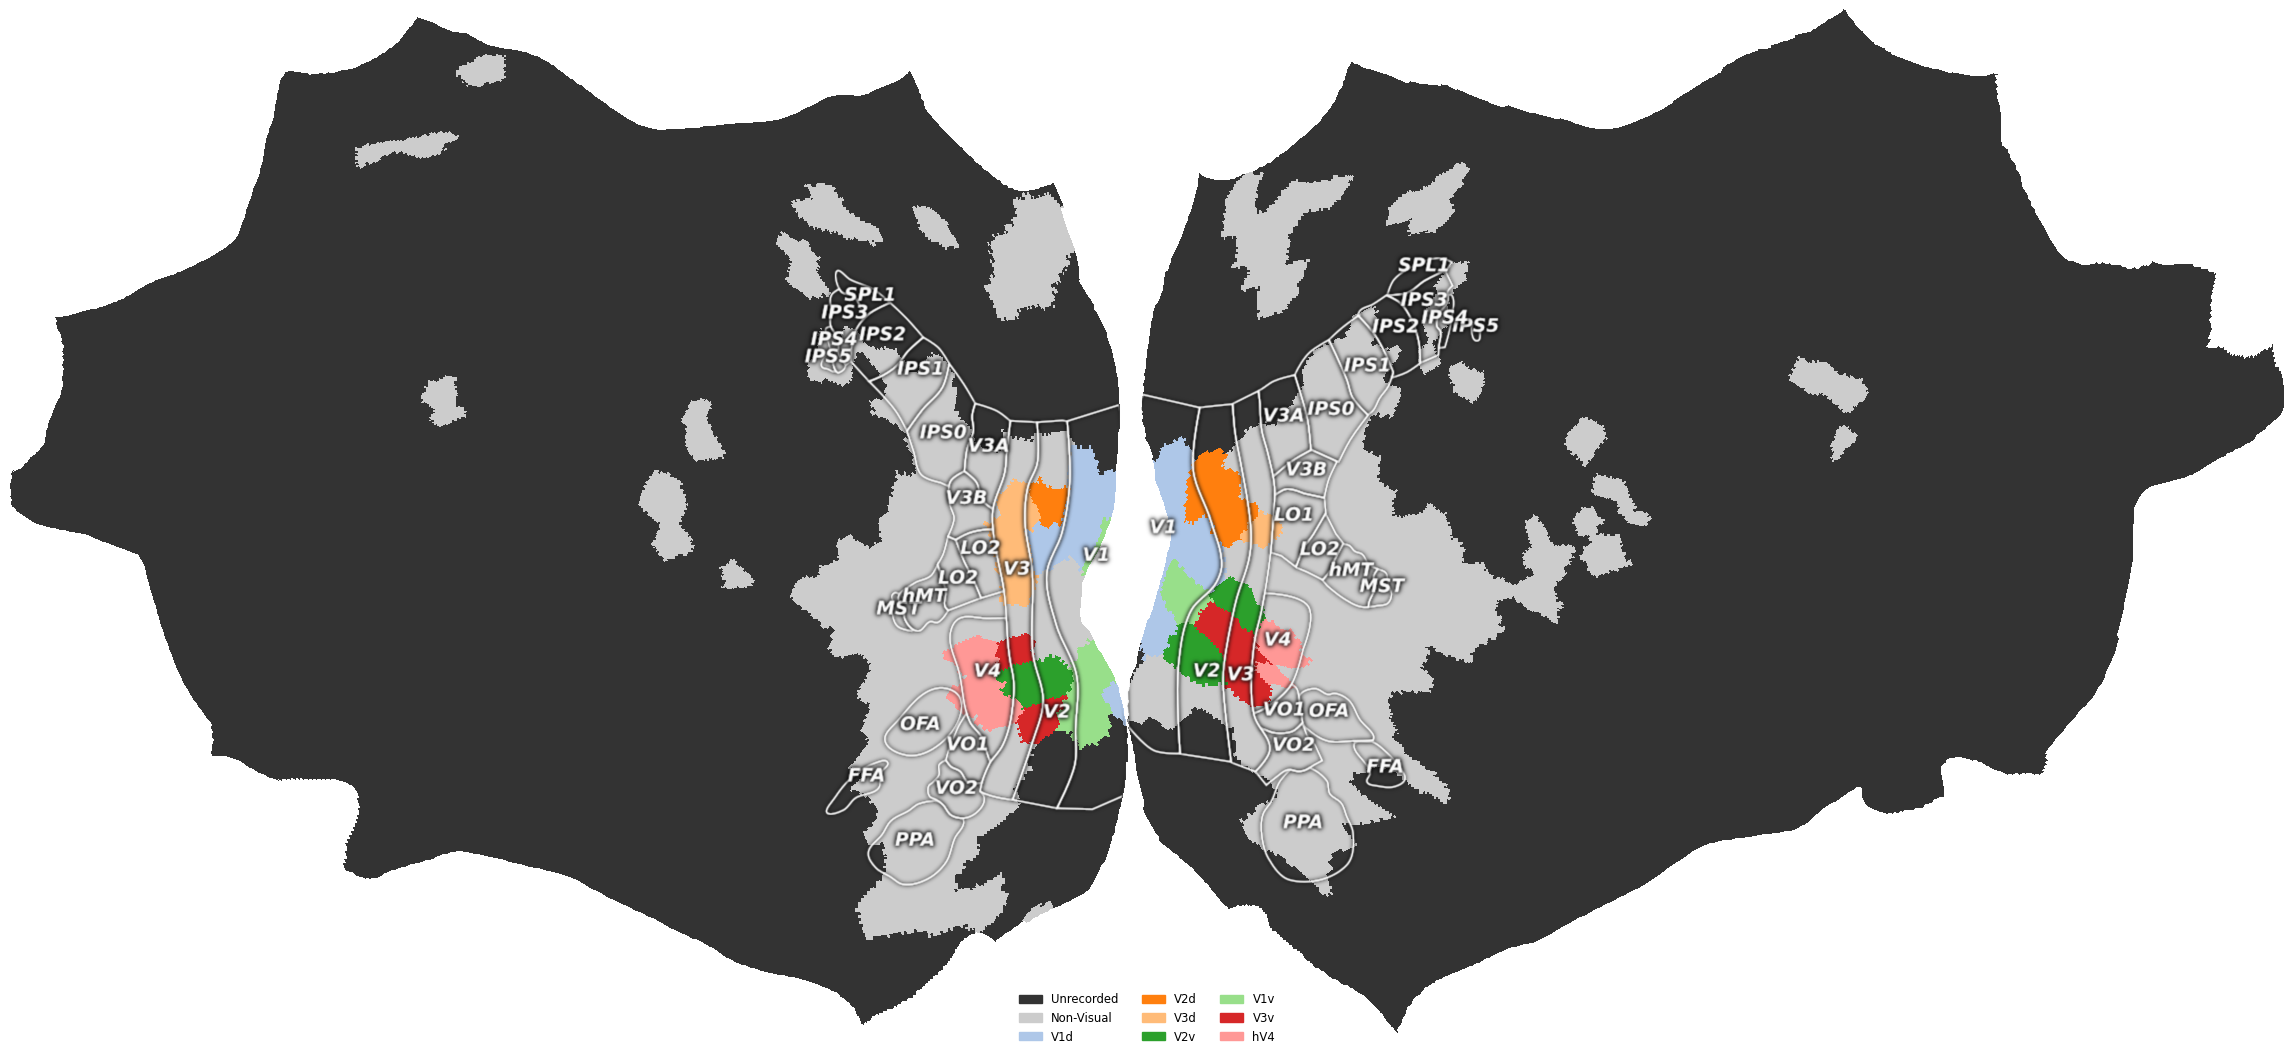


Visual ROI Results:
Shown ROIs: ['V1d', 'V2d', 'V3d', 'V2v', 'V1v', 'V3v', 'hV4']
Non-visual/unlabeled parcels: 193/200 (96.5%)

Visualizing only face-selective ROIs, all other parcels shown as unlabeled:
Cortex data shape: (327684,) (expected: 327684)
ROI Group Filter: ['OFA', 'FFA-1', 'FFA-2']
Showing 3 ROIs from group, 197/200 parcels as unlabeled (98.5%)
Coverage: 51,543 parcel vertices, 276,141 unrecorded vertices


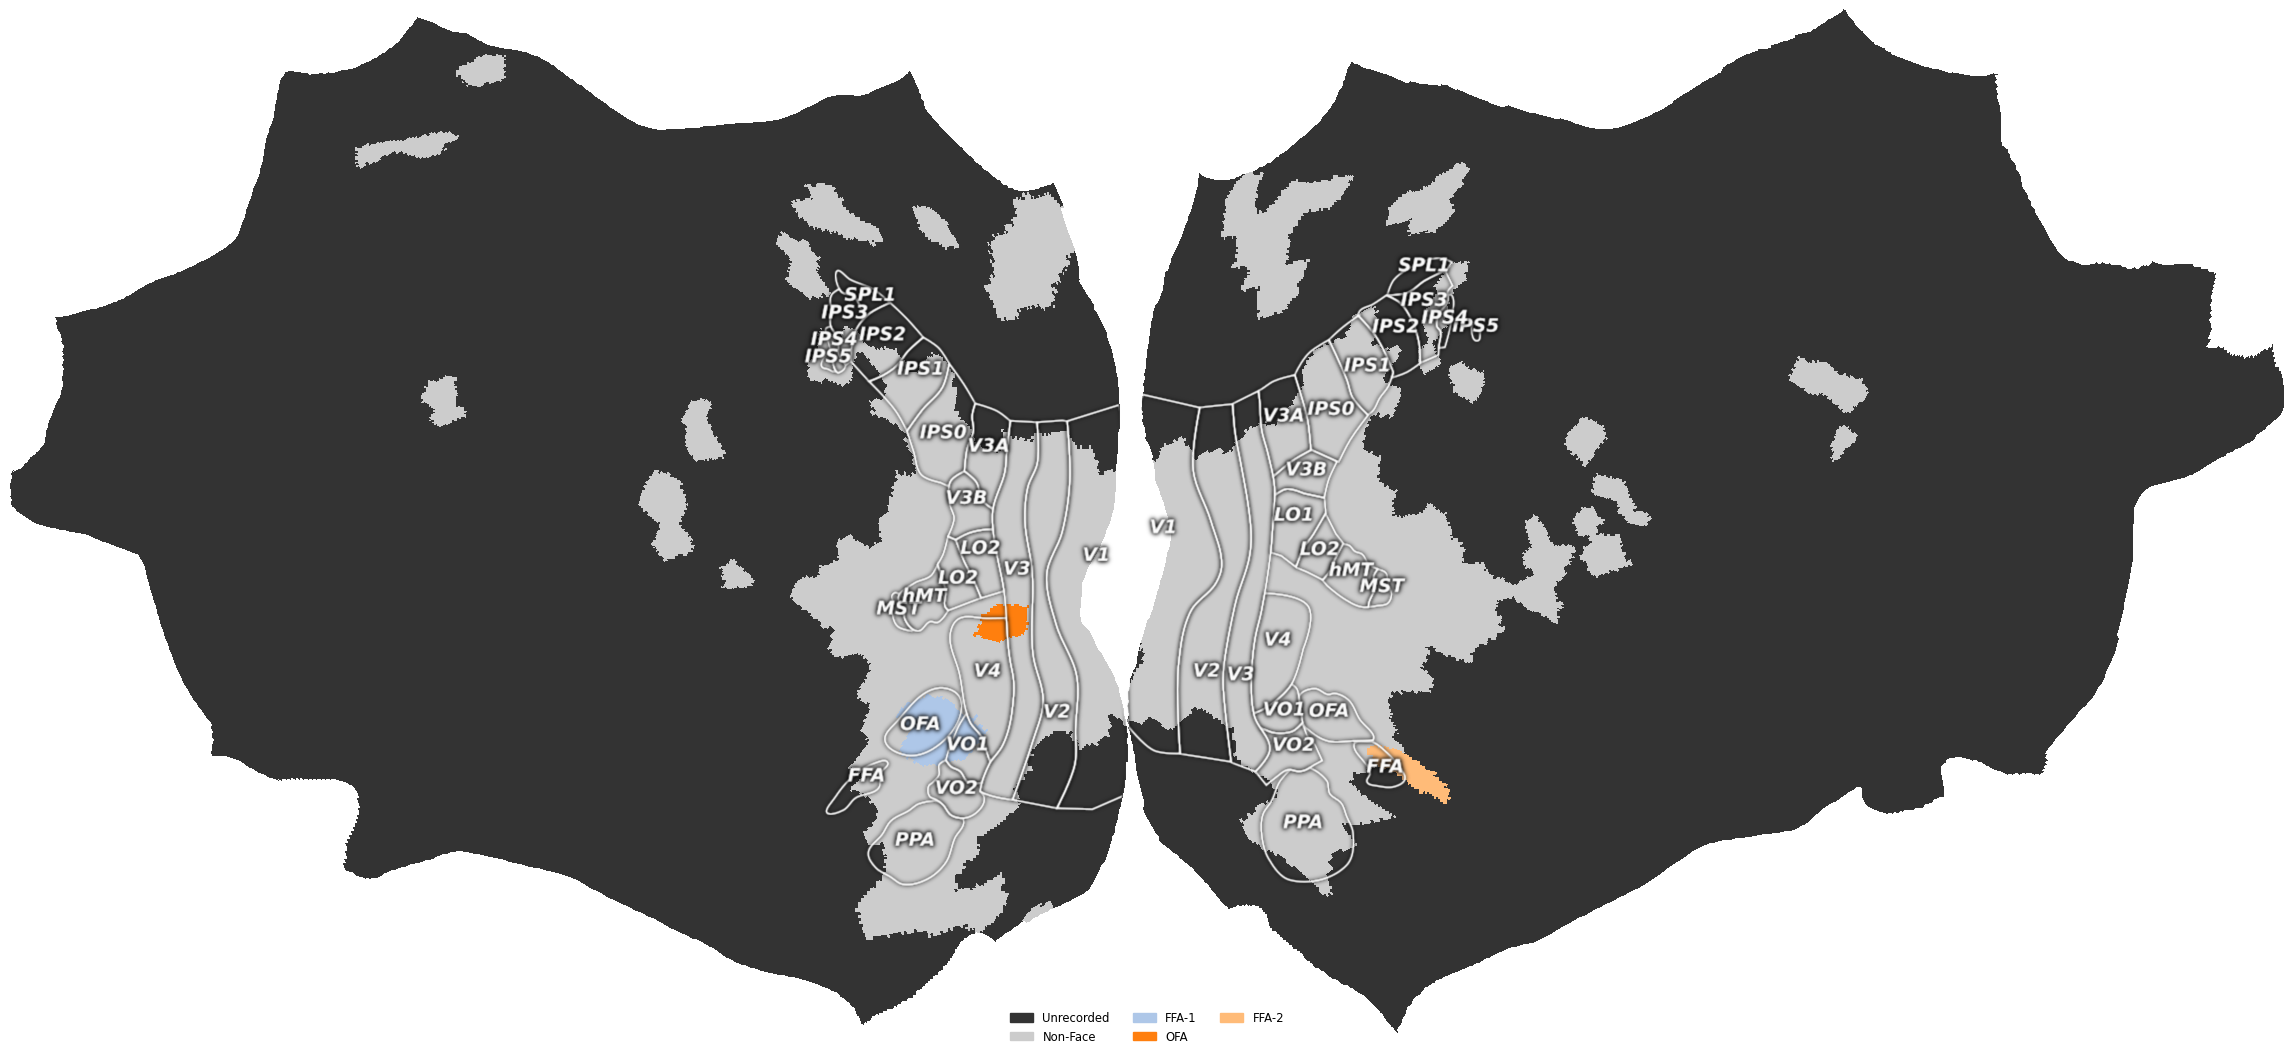


Face ROI Results:
Shown ROIs: ['FFA-1', 'OFA', 'FFA-2']
Non-face/unlabeled parcels: 197/200 (98.5%)


In [10]:
# Test the roi_group parameter - visualize only visual areas (V1, V2, V3, V4)
visual_rois = ["V1v", "V1d", "V2v", "V2d", "V3v", "V3d", "hV4"]

print("Visualizing only visual ROIs (V1-V4), all other parcels shown as unlabeled:")
visual_result = visualize_parcels_by_roi(
    train_dataset, metadata, dominant_rois, all_roi_names, 
    subject="fsaverage",
    unlabeled_name="Non-Visual", 
    unrecorded_name="Unrecorded",
    roi_group=visual_rois,
    show_unlabeled_in_legend=True
)

print(f"\nVisual ROI Results:")
print(f"Shown ROIs: {visual_result['matched_rois']}")
print(f"Non-visual/unlabeled parcels: {visual_result['unlabeled_count']}/{visual_result['total_parcels']} ({visual_result['unlabeled_count']/visual_result['total_parcels']:.1%})")

# Test with face-selective areas
face_rois = ["OFA", "FFA-1", "FFA-2"]

print("\n" + "="*60)
print("Visualizing only face-selective ROIs, all other parcels shown as unlabeled:")
face_result = visualize_parcels_by_roi(
    train_dataset, metadata, dominant_rois, all_roi_names, 
    subject="fsaverage",
    unlabeled_name="Non-Face", 
    unrecorded_name="Unrecorded",
    roi_group=face_rois,
    show_unlabeled_in_legend=True
)

print(f"\nFace ROI Results:")
print(f"Shown ROIs: {face_result['matched_rois']}")
print(f"Non-face/unlabeled parcels: {face_result['unlabeled_count']}/{face_result['total_parcels']} ({face_result['unlabeled_count']/face_result['total_parcels']:.1%})")

In [ ]:
def visualize_all_parcels(
    dataset, subject="fsaverage", with_curvature=True, 
    background_color=(0.3, 0.3, 0.3, 1.0), use_random_colors=False
):
    """
    Visualize all parcels in the dataset, regardless of ROI labels.
    Each parcel gets a unique color to show the complete parcel structure.
    
    Args:
        dataset: The brain dataset with parcel information
        subject: Pycortex subject name (default: "fsaverage")
        with_curvature: Whether to show brain curvature
        background_color: Color for non-parcel areas
        use_random_colors: If True, use random colors; if False, use systematic colormap
    """
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)
    
    # Get selected voxel indices for each parcel
    sel_vox = dataset.get_selected_voxel_indices()
    
    # Count total number of parcels
    n_lh_parcels = len(sel_vox['lh'])
    n_rh_parcels = len(sel_vox['rh'])
    total_parcels = n_lh_parcels + n_rh_parcels
    
    print(f"Visualizing {total_parcels} parcels ({n_lh_parcels} LH + {n_rh_parcels} RH)")
    
    # Use correct hemisphere sizes for fsaverage subject
    if subject == "fsaverage":
        lh_hemi_size = 163842  # Standard fsaverage left hemisphere vertex count
        rh_hemi_size = 163842  # Standard fsaverage right hemisphere vertex count
    else:
        # For other subjects, get the actual vertex counts
        surfs = [cortex.polyutils.Surface(*d) for d in cortex.db.get_surf(subject, "fiducial")]
        lh_hemi_size = surfs[0].pts.shape[0]
        rh_hemi_size = surfs[1].pts.shape[0]
    
    print(f"Using hemisphere sizes: LH={lh_hemi_size}, RH={rh_hemi_size}")
    
    # Initialize hemisphere arrays with background (label 0)
    lh_labels = np.zeros(lh_hemi_size, dtype=np.int32)
    rh_labels = np.zeros(rh_hemi_size, dtype=np.int32)
    
    # Paint each parcel with a unique label
    parcel_label = 1  # Start from 1 (0 is background)
    
    # Left hemisphere parcels
    for parcel_idx, parcel_vox in enumerate(sel_vox['lh']):
        vox = parcel_vox.cpu().numpy() if isinstance(parcel_vox, torch.Tensor) else np.asarray(parcel_vox)
        if vox.size > 0:
            # Make sure voxel indices are within bounds
            valid_vox = vox[vox < lh_hemi_size]
            if len(valid_vox) > 0:
                lh_labels[valid_vox] = parcel_label
            parcel_label += 1
    
    # Right hemisphere parcels
    for parcel_idx, parcel_vox in enumerate(sel_vox['rh']):
        vox = parcel_vox.cpu().numpy() if isinstance(parcel_vox, torch.Tensor) else np.asarray(parcel_vox)
        if vox.size > 0:
            # Make sure voxel indices are within bounds
            valid_vox = vox[vox < rh_hemi_size]
            if len(valid_vox) > 0:
                rh_labels[valid_vox] = parcel_label
            parcel_label += 1
    
    # Create colormap
    if use_random_colors:
        # Random colors for each parcel
        np.random.seed(42)  # For reproducibility
        colors = np.random.rand(total_parcels + 1, 4)
        colors[:, 3] = 1.0  # Full alpha
        colors[0] = background_color  # Background color
    else:
        # Systematic colormap using multiple standard colormaps
        # Use a mix of different colormaps to get enough distinct colors
        base_cmaps = [plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c, plt.cm.Set3]
        colors = [background_color]
        
        for i in range(total_parcels):
            cmap_idx = i % len(base_cmaps)
            color_idx = (i // len(base_cmaps)) % 20
            color = base_cmaps[cmap_idx](color_idx / 19.0)
            colors.append(color)
        
        colors = np.array(colors)
    
    cmap = ListedColormap(colors)
    
    # Combine hemispheres
    cortex_data = np.concatenate([lh_labels, rh_labels])
    print(f"Final cortex data shape: {cortex_data.shape} (expected: {lh_hemi_size + rh_hemi_size})")
    
    # Create vertex object and visualize
    vertex_data = cortex.Vertex(
        cortex_data, 
        subject=subject, 
        cmap=cmap,
        vmin=0,
        vmax=total_parcels
    )
    
    with suppress_print():
        fig = cortex.quickflat.make_figure(vertex_data, with_curvature=with_curvature, with_colorbar=False)
    
    # plt.title(f"All {total_parcels} Schaefer Parcels\n({n_lh_parcels} LH + {n_rh_parcels} RH)")
    os.chdir("/engram/nklab/pf2477/brain_decoding/")
    plt.savefig('figures/appendix_schaefer_parcellation.pdf', format='pdf')
    plt.show()


    return {
        'n_lh_parcels': n_lh_parcels,
        'n_rh_parcels': n_rh_parcels,
        'total_parcels': total_parcels,
        'lh_labels': lh_labels,
        'rh_labels': rh_labels
    }

Visualizing all parcels with systematic colors:
Visualizing 200 parcels (100 LH + 100 RH)
Using hemisphere sizes: LH=163842, RH=163842
Final cortex data shape: (327684,) (expected: 327684)


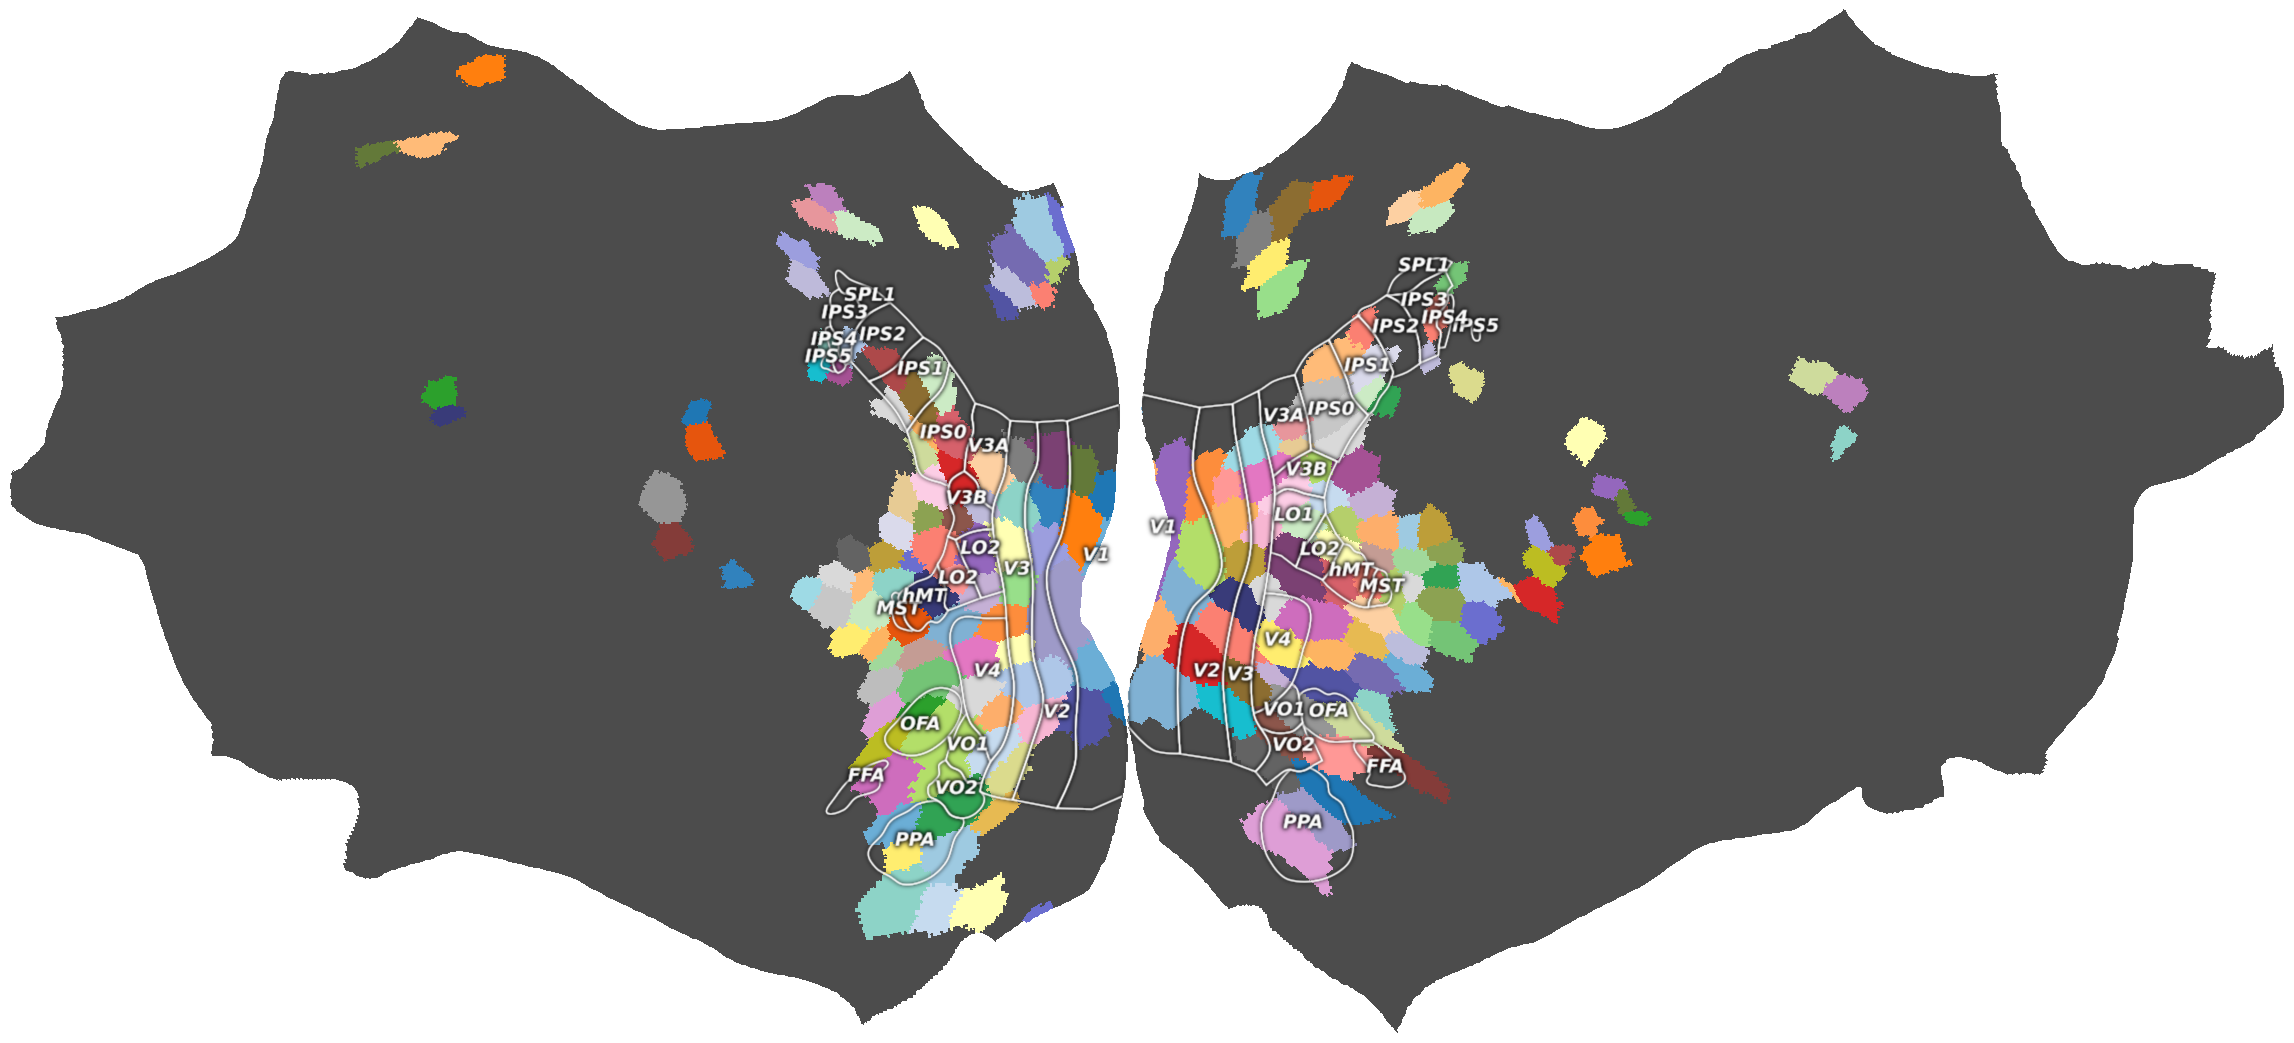


Results:
Total parcels visualized: 200
Left hemisphere: 100 parcels
Right hemisphere: 100 parcels


In [19]:
# Test the new function to visualize all parcels
print("Visualizing all parcels with systematic colors:")
result1 = visualize_all_parcels(train_dataset, subject="fsaverage", use_random_colors=False)

print(f"\nResults:")
print(f"Total parcels visualized: {result1['total_parcels']}")
print(f"Left hemisphere: {result1['n_lh_parcels']} parcels")
print(f"Right hemisphere: {result1['n_rh_parcels']} parcels")